# Chapter 22 Supplements — High-Performance Computational Intelligence and Forecasting Technologies

## Why this notebook looks different from every other chapter's

Chapter 22 (by guest authors Kesheng Wu & Horst D. Simon of LBNL) is a
**narrative survey**, not a formula chapter — it describes the CIFT
project's HPC infrastructure (hardware, MPI, HDF5, ADIOS) and six case
studies (supernova detection, fusion plasma blob tracking, electricity
peak forecasting, the 2010 Flash Crash, VPIN calibration, and non-uniform
FFT for HFT detection). **There are no printed code snippets anywhere in
this chapter.** The full context and summary lives in `../README.md`.

This notebook covers two **optional teaching supplements** — not book
snippets, built to illustrate two of the chapter's genuinely applicable
ideas on our own real data:

- **Part 1**: an I/O format benchmark (CSV vs. Parquet), echoing the
  chapter's own headline HDF5-vs-ASCII 21x speedup story (§22.6.4) —
  single machine, not a real HPC cluster.
- **Part 2**: a non-uniform Fourier transform (§22.6.6) applied to our
  real, irregularly-timestamped BTC/TUSD trade data, since that's exactly
  the kind of data this technique is for.

(VPIN, the chapter's other headline algorithm, is **not** re-implemented
here — it's already built in Chapter 19 §19.5.2, since Ch22 doesn't define
it itself, just cites the same Easley/López de Prado/O'Hara 2011 paper.)


In [1]:
import os
import sys
import tempfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AFML_ROOT = r'C:\ws\AFML'
if not os.path.isdir(AFML_ROOT):
    AFML_ROOT = os.path.abspath('..')
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch22', 'hpc_supplements'))


## Part 1: I/O format benchmark (§22.6.4)

### Plain English
The chapter's headline finding: switching from a row-based text format
(ASCII) to a format built for analytical access (their HDF5) sped up
reading 10 years of S&P 500 quote data **21-fold** (3.5 hours → 604
seconds), and combined with indexing, computing the VPIN/HHI early-warning
indicators sped up **720-fold**. We don't have a real HPC cluster or HDF5
here — this is a single-machine echo of the *same underlying lesson* using
Parquet (a columnar, compressed format any pandas user can reach for)
against CSV, on our own real BTC/TUSD trade data.

### Why replicate the data
Our real dataset (9,205 trades) is too small on its own to show a
measurable format difference — matching the book's own approach in
§22.6.4 ("we replicated the data 10 times"), we replicate ours too.


In [2]:
from io_benchmark import load_real_trades, replicate_data, benchmark_write_read, benchmark_column_subset_read

csv_path = os.path.join(AFML_ROOT, 'input_data', 'BTCTUSD-trades-2026-03.csv')
trades = load_real_trades(csv_path)
print(f'Real BTC/TUSD trades: {len(trades)} rows, {trades["ts"].min()} to {trades["ts"].max()}')

n_replicas = 200
big = replicate_data(trades[['trade_id', 'price', 'qty', 'quote_qty', 'time_us']], n_replicas)
print(f'Replicated {n_replicas}x for a measurable benchmark: {len(big):,} rows')


Real BTC/TUSD trades: 9205 rows, 2026-03-01 00:00:09.088203 to 2026-03-31 23:25:52.396841


Replicated 200x for a measurable benchmark: 1,841,000 rows


In [3]:
tmp_dir = tempfile.mkdtemp()
result = benchmark_write_read(big, tmp_dir, n_repeats=3)
for fmt in ('csv', 'parquet'):
    r = result[fmt]
    print(f"{fmt:8s}: write={r['write_s']:.4f}s  read={r['read_s']:.4f}s  size={r['size_bytes']/1e6:.2f} MB")

read_speedup = result['csv']['read_s'] / result['parquet']['read_s']
size_ratio = result['csv']['size_bytes'] / result['parquet']['size_bytes']
print(f'\nParquet read speedup vs CSV: {read_speedup:.2f}x')
print(f'Parquet file size vs CSV: {size_ratio:.2f}x smaller')

col_result = benchmark_column_subset_read(big, tmp_dir, column='price', n_repeats=3)
col_speedup = col_result['csv_column_read_s'] / col_result['parquet_column_read_s']
print(f"\nSingle-column ('price') read: CSV={col_result['csv_column_read_s']:.4f}s, "
      f"Parquet={col_result['parquet_column_read_s']:.4f}s -> {col_speedup:.2f}x speedup")
print("This is the closest single-machine analogy to the book's own HDF5-indexing result "
      "(Figure 22.8): a columnar format can skip data you didn't ask for; a row-based text "
      "format has to scan every row regardless of how many columns you actually want.")


csv     : write=4.6569s  read=0.7746s  size=97.36 MB
parquet : write=0.1517s  read=0.2106s  size=13.55 MB

Parquet read speedup vs CSV: 3.68x
Parquet file size vs CSV: 7.18x smaller



Single-column ('price') read: CSV=0.4403s, Parquet=0.0127s -> 34.75x speedup
This is the closest single-machine analogy to the book's own HDF5-indexing result (Figure 22.8): a columnar format can skip data you didn't ask for; a row-based text format has to scan every row regardless of how many columns you actually want.


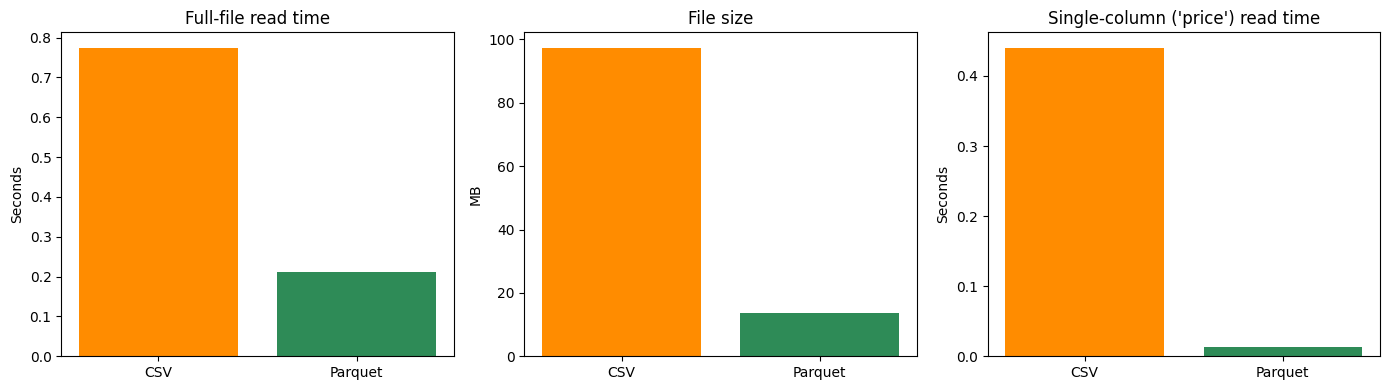

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['CSV', 'Parquet'], [result['csv']['read_s'], result['parquet']['read_s']],
            color=['darkorange', 'seagreen'])
axes[0].set_title('Full-file read time')
axes[0].set_ylabel('Seconds')

axes[1].bar(['CSV', 'Parquet'], [result['csv']['size_bytes']/1e6, result['parquet']['size_bytes']/1e6],
            color=['darkorange', 'seagreen'])
axes[1].set_title('File size')
axes[1].set_ylabel('MB')

axes[2].bar(['CSV', 'Parquet'], [col_result['csv_column_read_s'], col_result['parquet_column_read_s']],
            color=['darkorange', 'seagreen'])
axes[2].set_title("Single-column ('price') read time")
axes[2].set_ylabel('Seconds')

plt.tight_layout()
plt.show()


## Part 2: Non-uniform Fourier transform (§22.6.6)

### Plain English
Normal FFT assumes evenly-spaced samples. Trade arrival times aren't
evenly spaced — trades happen in bursts, not on a metronome. The book
uses a non-uniform FFT to look for periodic structure directly in
irregularly-timestamped price and volume series (finding, for instance, a
sharp once-per-minute signature consistent with TWAP algorithms in their
natural gas futures data). Our real BTC/TUSD trade data has exactly the
same "irregular timestamps" property, so this is a genuinely applicable
technique on our own data — implemented directly from the math (a direct
non-uniform discrete Fourier transform), since there's no snippet to
translate and our dataset (9,205 points) is small enough that the direct,
un-approximated sum is trivially fast.

### The math
$$X(f) = \sum_n x_n \, e^{-2\pi i f t_n}$$
evaluated directly at each candidate frequency $f$, for arbitrary
(non-uniform) sample times $t_n$.

### Hand-traced check
times=[0,1], values=[1,1], freq=0.5: $e^{-i\pi \cdot 0} = 1$,
$e^{-i\pi \cdot 1} = -1$ → $X(0.5) = 1\cdot 1 + 1\cdot(-1) = 0$
(destructive cancellation at exactly the Nyquist-like frequency for this
2-point spacing).


In [5]:
from nufft_analysis import nudft, power_spectrum, price_return_series, trade_size_series, days_since_start

# Hand-traced check
check = nudft([0, 1], [1, 1], [0.5])
print('nudft hand-traced check:', check, ' (expected 0+0j)')
assert np.isclose(check[0], 0.0)
print('Matches hand trace.')


nudft hand-traced check: [0.-1.2246468e-16j]  (expected 0+0j)
Matches hand trace.


In [6]:
span_days = (trades['ts'].max() - trades['ts'].min()).total_seconds() / 86400
print(f'Real trade data span: {span_days:.1f} days, {len(trades)} trades '
      f'(~{len(trades)/span_days:.0f} trades/day average)')
print("This is far sparser than the book's own year-long, higher-frequency futures data "
      "-- a once-per-minute search (like the book's TWAP finding) is not realistically "
      "resolvable here. We search daily/sub-daily frequencies instead, and report honestly "
      "whatever the spectrum shows.")

freqs = np.linspace(0.05, 4.0, 400)

times_days, log_returns = price_return_series(trades)
return_spec = power_spectrum(times_days, log_returns, freqs)
peak_idx = np.argmax(return_spec['magnitude'])
print(f"\nPrice-return spectrum: peak at {freqs[peak_idx]:.3f} cycles/day "
      f"(magnitude {return_spec['magnitude'][peak_idx]:.4f})")

times_days2, qty = trade_size_series(trades)
qty_centered = qty - qty.mean()
qty_spec = power_spectrum(times_days2, qty_centered, freqs)
peak_idx2 = np.argmax(qty_spec['magnitude'])
print(f"Trade-size spectrum:   peak at {freqs[peak_idx2]:.3f} cycles/day "
      f"(magnitude {qty_spec['magnitude'][peak_idx2]:.4f})")

return_flatness = return_spec['magnitude'].std() / return_spec['magnitude'].mean()
qty_flatness = qty_spec['magnitude'].std() / qty_spec['magnitude'].mean()
print(f'\nSpectral flatness (std/mean of magnitude; low = flat, no standout peak):')
print(f'  price returns: {return_flatness:.3f}')
print(f'  trade size:    {qty_flatness:.3f}')


Real trade data span: 31.0 days, 9205 trades (~297 trades/day average)
This is far sparser than the book's own year-long, higher-frequency futures data -- a once-per-minute search (like the book's TWAP finding) is not realistically resolvable here. We search daily/sub-daily frequencies instead, and report honestly whatever the spectrum shows.

Price-return spectrum: peak at 2.980 cycles/day (magnitude 0.3281)


Trade-size spectrum:   peak at 0.505 cycles/day (magnitude 8.9660)

Spectral flatness (std/mean of magnitude; low = flat, no standout peak):
  price returns: 0.543
  trade size:    0.438


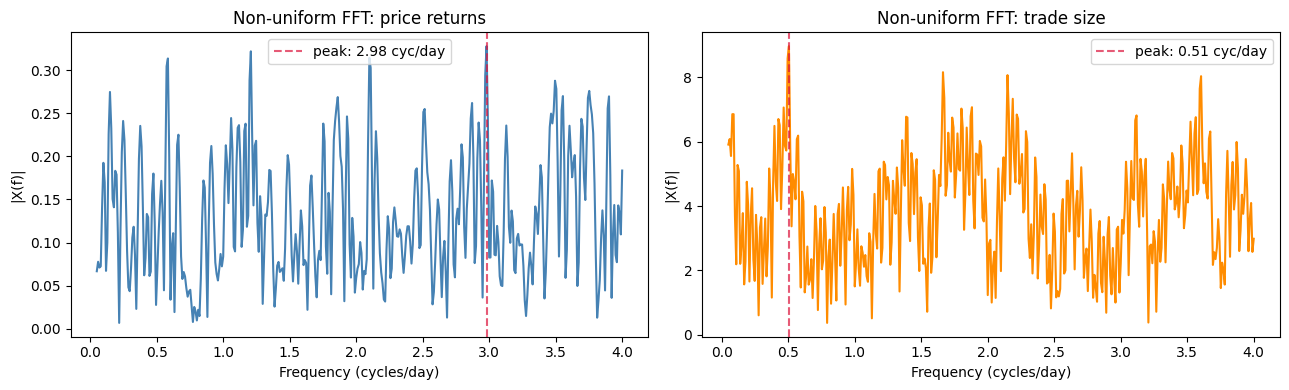

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(freqs, return_spec['magnitude'], color='steelblue')
axes[0].axvline(freqs[peak_idx], color='crimson', linestyle='--', alpha=0.7,
                label=f'peak: {freqs[peak_idx]:.2f} cyc/day')
axes[0].set_title('Non-uniform FFT: price returns')
axes[0].set_xlabel('Frequency (cycles/day)')
axes[0].set_ylabel('|X(f)|')
axes[0].legend()

axes[1].plot(freqs, qty_spec['magnitude'], color='darkorange')
axes[1].axvline(freqs[peak_idx2], color='crimson', linestyle='--', alpha=0.7,
                label=f'peak: {freqs[peak_idx2]:.2f} cyc/day')
axes[1].set_title('Non-uniform FFT: trade size')
axes[1].set_xlabel('Frequency (cycles/day)')
axes[1].set_ylabel('|X(f)|')
axes[1].legend()

plt.tight_layout()
plt.show()


### Honest read of the result

Neither spectrum shows a sharp, dominant peak the way the book's natural
gas futures example did (theirs was >10x stronger than neighboring
frequencies, in a dataset with far higher trade density over a full
year). Ours are relatively flat, with the tallest points landing around
~3 cycles/day (price returns) and ~0.5 cycles/day (trade size) — plausible
but not the kind of "clearly intentional algorithmic footprint" signal
the book reports finding in denser data. At ~300 trades/day over one
month, this dataset simply doesn't have the density to resolve fine
periodic structure the way a full year of high-frequency futures data
does — a real, honestly-reported limitation of applying this technique
to a smaller dataset, not a flaw in the technique itself.


## TDD Test Results

```
$ python -m pytest ch22/hpc_supplements/ -v      (from repo root)
$ python -m pytest -v                              (from inside module folder)

test_hpc_supplements.py -- 16 passed
```

Unlike every other chapter, io_benchmark.py's tests check STRUCTURAL
correctness (round-trip fidelity, non-negative durations) rather than
exact timing values, since wall-clock timings are inherently
non-deterministic -- a deliberate, documented departure from the
hand-traced-exact-value convention used elsewhere. nufft_analysis.py's
tests use hand-traced exact values as usual, since it's pure math.
